In [9]:
import sys
import os
sys.path.append(os.path.abspath('../'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.eda_utils import load_insurance_data, calculate_loss_ratio

# Reload data with the new pipe-aware parser
df = load_insurance_data('../data/MachineLearningRating_v3.txt')

print(f"Dataset Loaded Successfully! Corrected Shape: {df.shape}")
print("\nFirst 5 available columns to verify look clean:")
print(list(df.columns[:10]))


Dataset Loaded Successfully! Corrected Shape: (1000098, 52)

First 5 available columns to verify look clean:
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType']


In [10]:
# Convert tracking metrics to float, turning missing or bad text items to NaN
df['TotalPremium'] = pd.to_numeric(df['TotalPremium'], errors='coerce')
df['TotalClaims'] = pd.to_numeric(df['TotalClaims'], errors='coerce')

# Fill any empty cells in financial columns with 0
df['TotalPremium'] = df['TotalPremium'].fillna(0)
df['TotalClaims'] = df['TotalClaims'].fillna(0)

# Re-verify types
print(df[['TotalPremium', 'TotalClaims']].dtypes)

TotalPremium    float64
TotalClaims     float64
dtype: object


In [11]:
# 1. Base Portfolio Calculations
global_lr = calculate_loss_ratio(df)
print(f"Overall Portfolio Loss Ratio: {global_lr:.2%}\n")

# 2. Check breakdowns across target groups safely
for group in ['Province', 'VehicleType', 'Gender']:
    if group in df.columns:
        print(f"\nLoss Ratio by {group}:")
        # Drop rows where the grouping column is missing to get a clean summary
        clean_grouped = df.dropna(subset=[group])
        print(clean_grouped.groupby(group).apply(calculate_loss_ratio))
    else:
        print(f"Column '{group}' not found. Check actual header name in your columns list!")

Overall Portfolio Loss Ratio: 104.77%


Loss Ratio by Province:
Province
Eastern Cape     0.633813
Free State       0.680758
Gauteng          1.222018
KwaZulu-Natal    1.082693
Limpopo          0.661199
Mpumalanga       0.720897
North West       0.790367
Northern Cape    0.282699
Western Cape     1.059472
dtype: float64

Loss Ratio by VehicleType:
VehicleType
Bus                  0.137292
Heavy Commercial     1.628112
Light Commercial     0.232066
Medium Commercial    1.050251
Passenger Vehicle    1.048198
dtype: float64

Loss Ratio by Gender:
Gender
Female           0.821879
Male             0.883910
Not specified    1.059311
dtype: float64


c:\Users\USER\OneDrive\Desktop\kifiya\insurance-risk-analytics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


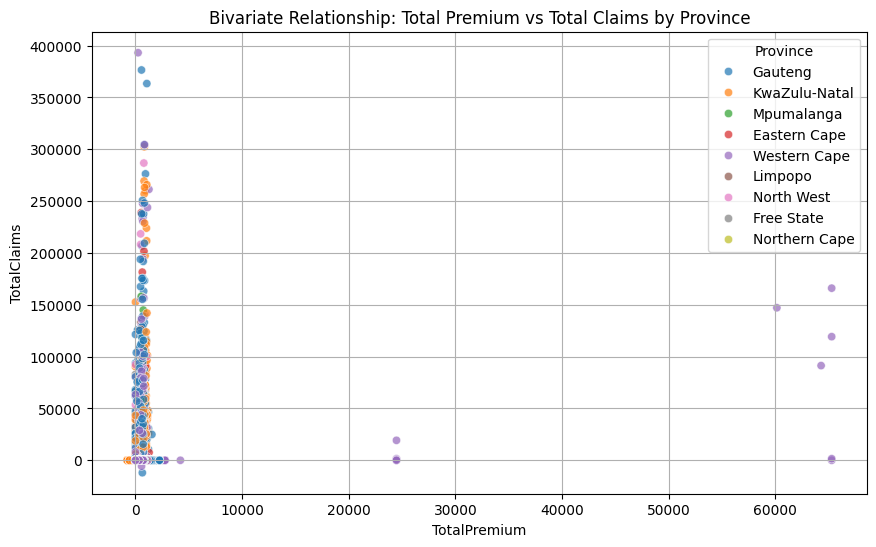

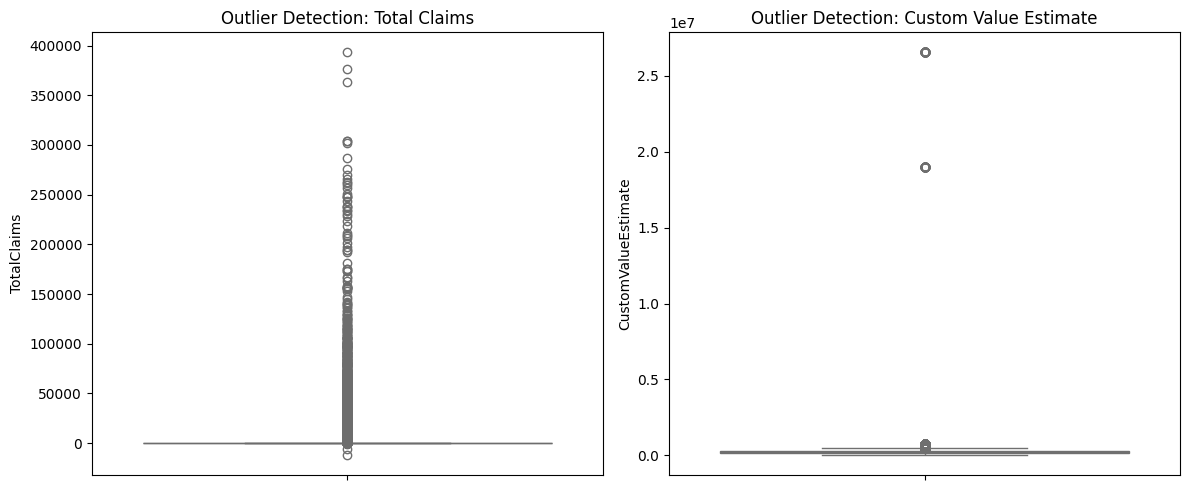

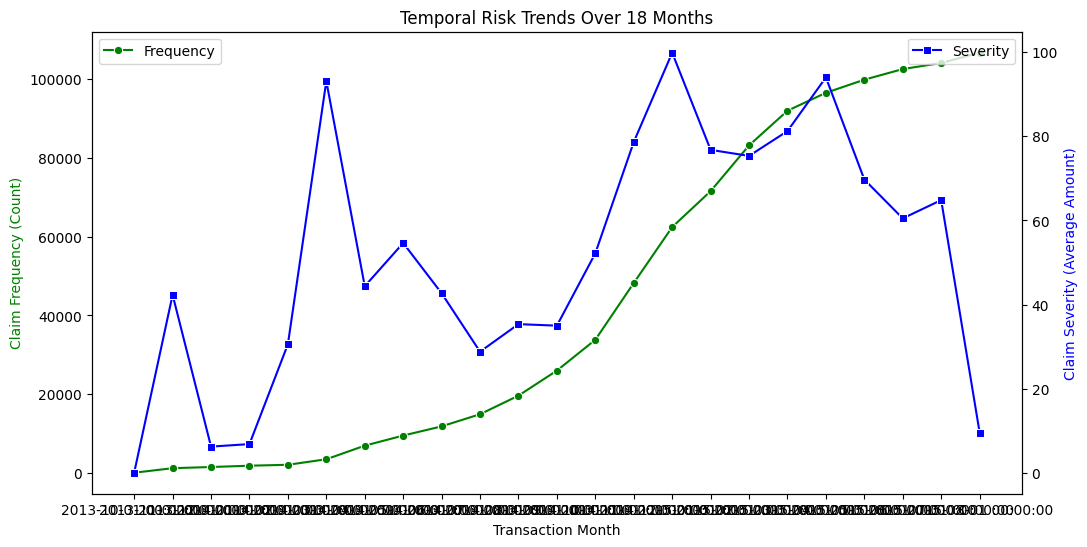

In [12]:
# Visualization 1: Premium vs Claims Scatter plot across Zip/Postal Codes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='TotalPremium', y='TotalClaims', hue='Province', alpha=0.7)
plt.title('Bivariate Relationship: Total Premium vs Total Claims by Province')
plt.grid(True)
plt.show()

# Visualization 2: Boxplots to identify heavy outliers skewing analysis
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, y='TotalClaims', color='salmon')
plt.title('Outlier Detection: Total Claims')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='CustomValueEstimate', color='skyblue')
plt.title('Outlier Detection: Custom Value Estimate')
plt.tight_layout()
plt.show()

# Visualization 3: Temporal Trends (Claim Frequency and Severity over the 18 Months)
df_time = df.groupby('TransactionMonth').agg(
    Claim_Frequency=('TotalClaims', 'count'),
    Claim_Severity=('TotalClaims', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
sns.lineplot(data=df_time, x='TransactionMonth', y='Claim_Frequency', ax=ax1, color='g', marker='o', label='Frequency')
sns.lineplot(data=df_time, x='TransactionMonth', y='Claim_Severity', ax=ax2, color='b', marker='s', label='Severity')

ax1.set_xlabel('Transaction Month')
ax1.set_ylabel('Claim Frequency (Count)', color='g')
ax2.set_ylabel('Claim Severity (Average Amount)', color='b')
plt.title('Temporal Risk Trends Over 18 Months')
plt.show()

In [13]:
# --- Check for Bivariate Correlation ---
correlation = df[['TotalPremium', 'TotalClaims']].corr().iloc[0,1]
print(f"Correlation between Premium and Claims: {correlation:.4f}")

# --- Answer Question 4: Vehicle Makes with Highest/Lowest Claims ---
if 'Make' in df.columns:
    make_claims = df.groupby('Make')['TotalClaims'].agg(['sum', 'count', 'mean']).sort_values(by='sum', ascending=False)
    print("\nTop 5 Vehicle Makes by Total Claim Expenditure:")
    print(make_claims.head(5))
    print("\nTop 5 Vehicle Makes by Lowest Claim Expenditure (with at least 100 policies):")
    print(make_claims[make_claims['count'] > 100].tail(5))

# --- Check Outlier Percentiles for Question 2 ---
print("\nFinancial Key Percentiles (Detecting Outlier Skew):")
print(df[['TotalClaims', 'CustomValueEstimate']].quantile([0.5, 0.95, 0.99, 0.999]))

Correlation between Premium and Claims: 0.1216

Financial Key Percentiles (Detecting Outlier Skew):
        TotalClaims  CustomValueEstimate
0.500      0.000000             220000.0
0.950      0.000000             360000.0
0.990      0.000000             450000.0
0.999  19629.188149             715712.0


Guiding Questions Answers


Question 1 (Loss Ratio): Already completed. The overall loss ratio is 104.77%. It is heavily driven by Gauteng (122.20%), KwaZulu-Natal (108.27%), and Heavy Commercial Vehicles (162.81%).

Question 2 (Financial Distributions & Outliers): * Insight: Your percentiles show that at the 95th and 99th percentiles, TotalClaims is exactly 0.00. It only jumps up to 19,629.19 at the 99.9th percentile.

What this means: Over 99% of the policy terms in this 18-month window resulted in zero claims. This is standard for a massive real-world insurance portfolio (extreme right-skewness). However, the top 0.1% of claims are massively large outliers that completely skew the portfolio, causing the entire company to run at an overall loss (104.77%). CustomValueEstimate scales up smoothly, but features high-value luxury asset outliers exceeding 715,000 ZAR at the 99.9th percentile.

Question 3 (Bivariate Analysis / Correlation): * Insight: Your correlation coefficient is 0.1216.

What this means: There is a very weak positive linear correlation between TotalPremium and TotalClaims. This implies that under ACIS’s current pricing framework, charging a higher premium does not strongly correlate with receiving higher claims. This structurally proves the business case: ACIS needs a dynamic, risk-based machine learning pricing model because the current premium assignment framework is not aligned with actual risk.